# **1. Perkenalan Dataset**


Dataset yang saya gunakan dalam eksperimen ini adalah "Heart Disease Dataset" dari Kaggle

Link Dataset:
[link](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)

Dataset ini memiliki 14 kolom data (13 fitur dan 1 target). Dataset ini dapat digunakan untuk melakukan klasifikasi biner dengan nilai 1 = beresiko kena penyakit jantung dan 0 = tidak beresiko kena penyakit jantung. 

Target tersebut dipengaruhi oleh 13 variabel fitur, yaitu:
1. Age = umur dalam tahun
2. Sex = jenis kelamin (1=male, 0 = female)
3. cp = jenis chest pain (0,1,2,3)
4. trestbps = tekanan darah dalam kondisi istirahat (dalam mmHg)
5. chol = kadar kolestrol serum dalam mg/dl
6. fbs = fasting blood sugar >120 mg/dl (1=true, 0=false)
7. restecg = hasil electrocardiographic ketika istirahat (0=normal, 1= ada kelainan)
8. thalach = detak jantung tertinggi
9. exang = nyeri dada yang disebabkan oleh aktivitas fisik (1=true, 0=false)
10. oldpeak = perubahan segmen ST pada EKG selama latihan
11. slope = kemiringan segmen ST pada puncak latihan (0,1,2)
12. ca = jumlah pembuluh darah utama yang terlihat di fluoroskopi (0,1,2,3)
13. thal = kondisi thalasemia

# **2. Import Library**

Berikut ini adalah daftar library yang digunakan dalam eksperimen ini:

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer

# **3. Memuat Dataset**

Pada tahapan memuat dataset ini, dapat dilihat bahwa terdapat 14 kolom data pada dataset ini (13 fitur dan 1 target). Lima baris teratas dari data ditampilkan pada tabel menggunakan fungsi head dari dataframe pandas.

In [16]:
df = pd.read_csv('../heart_raw/heart.csv')

display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi Terkait Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


Statistik dari Dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000




Jumlah data yang hilang atau NULL:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Jumlah data duplikat: 723




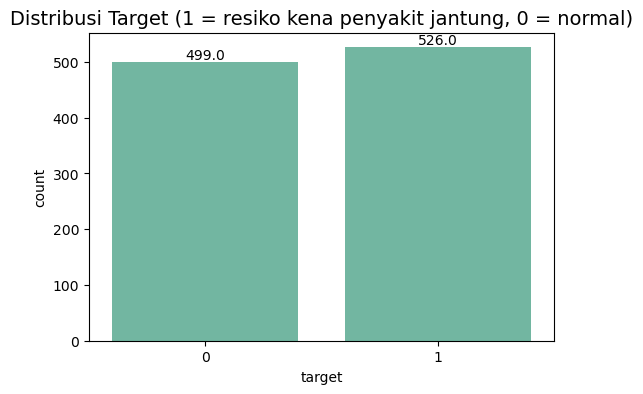

Distribusi Fitur Numerik:



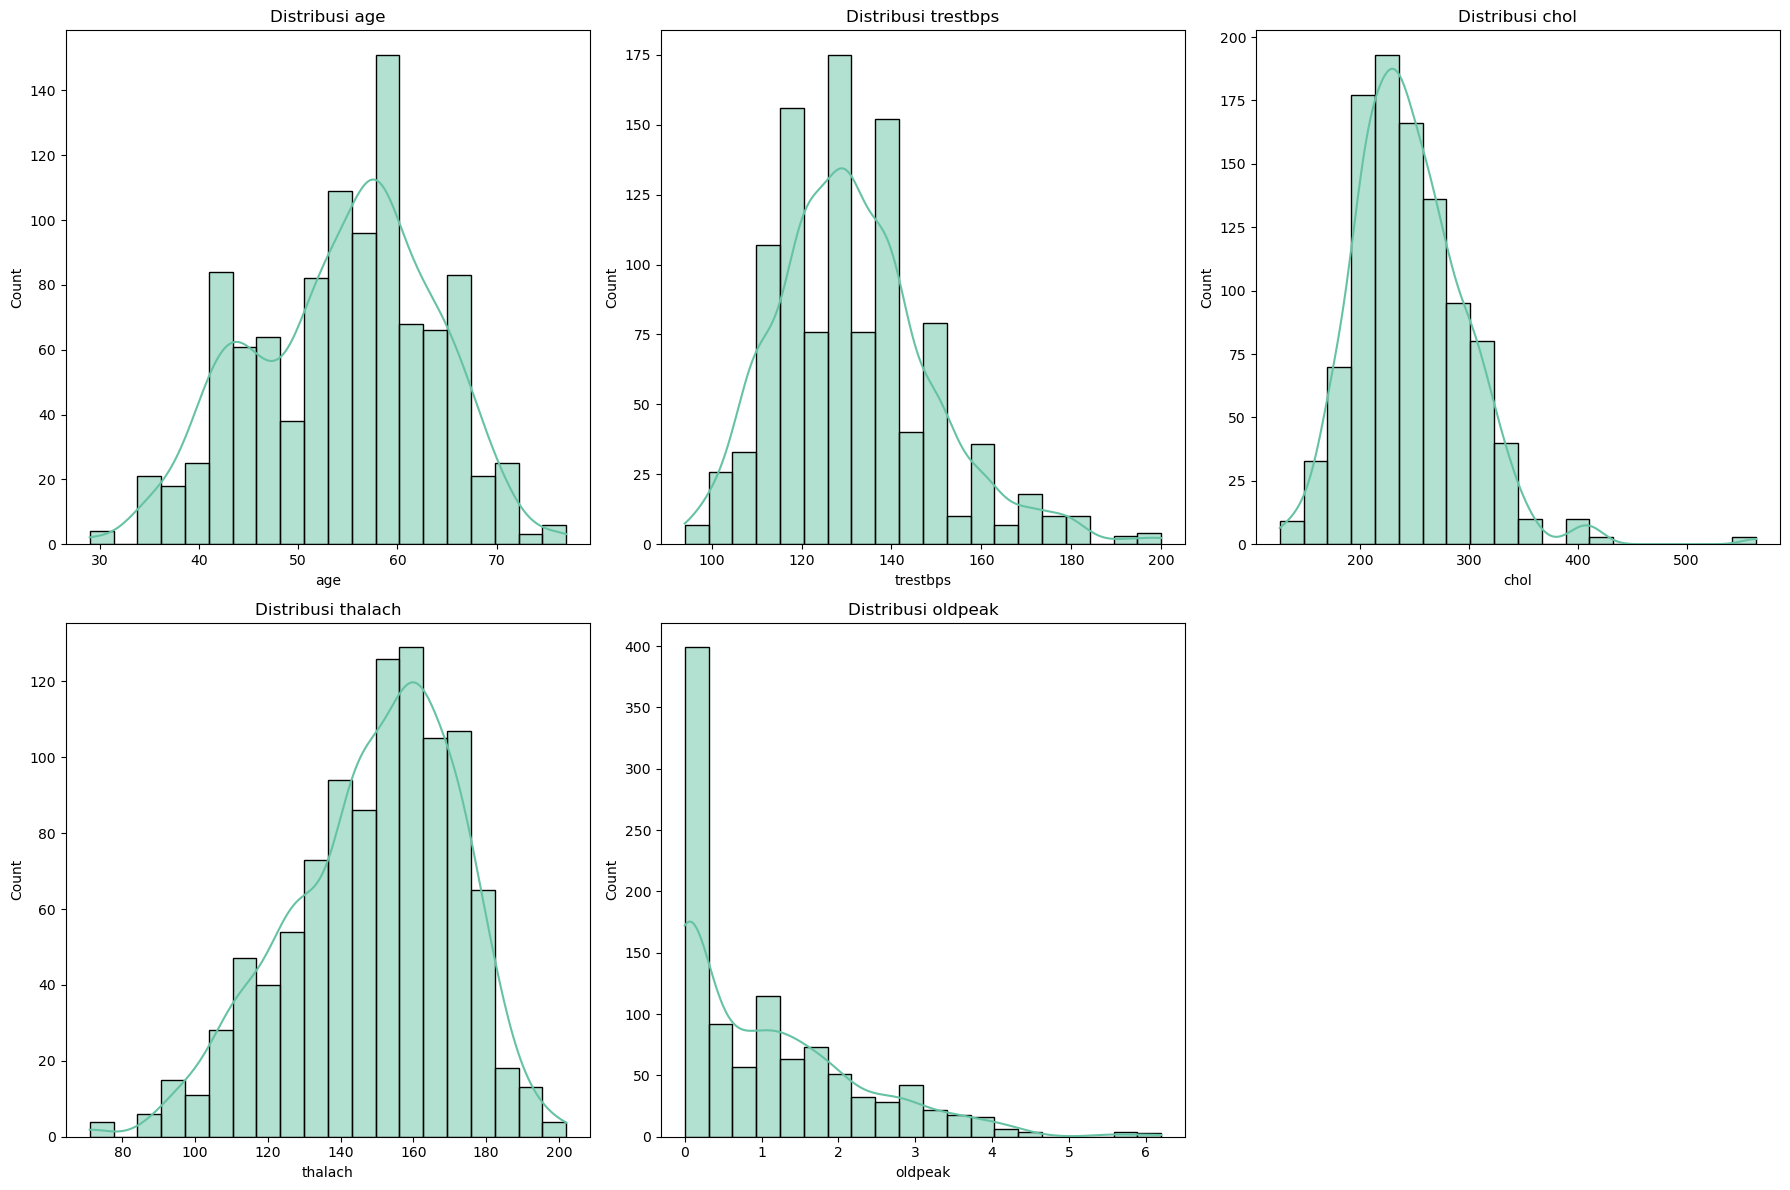

Distribusi Fitur Kategorik berdasarkan Target:



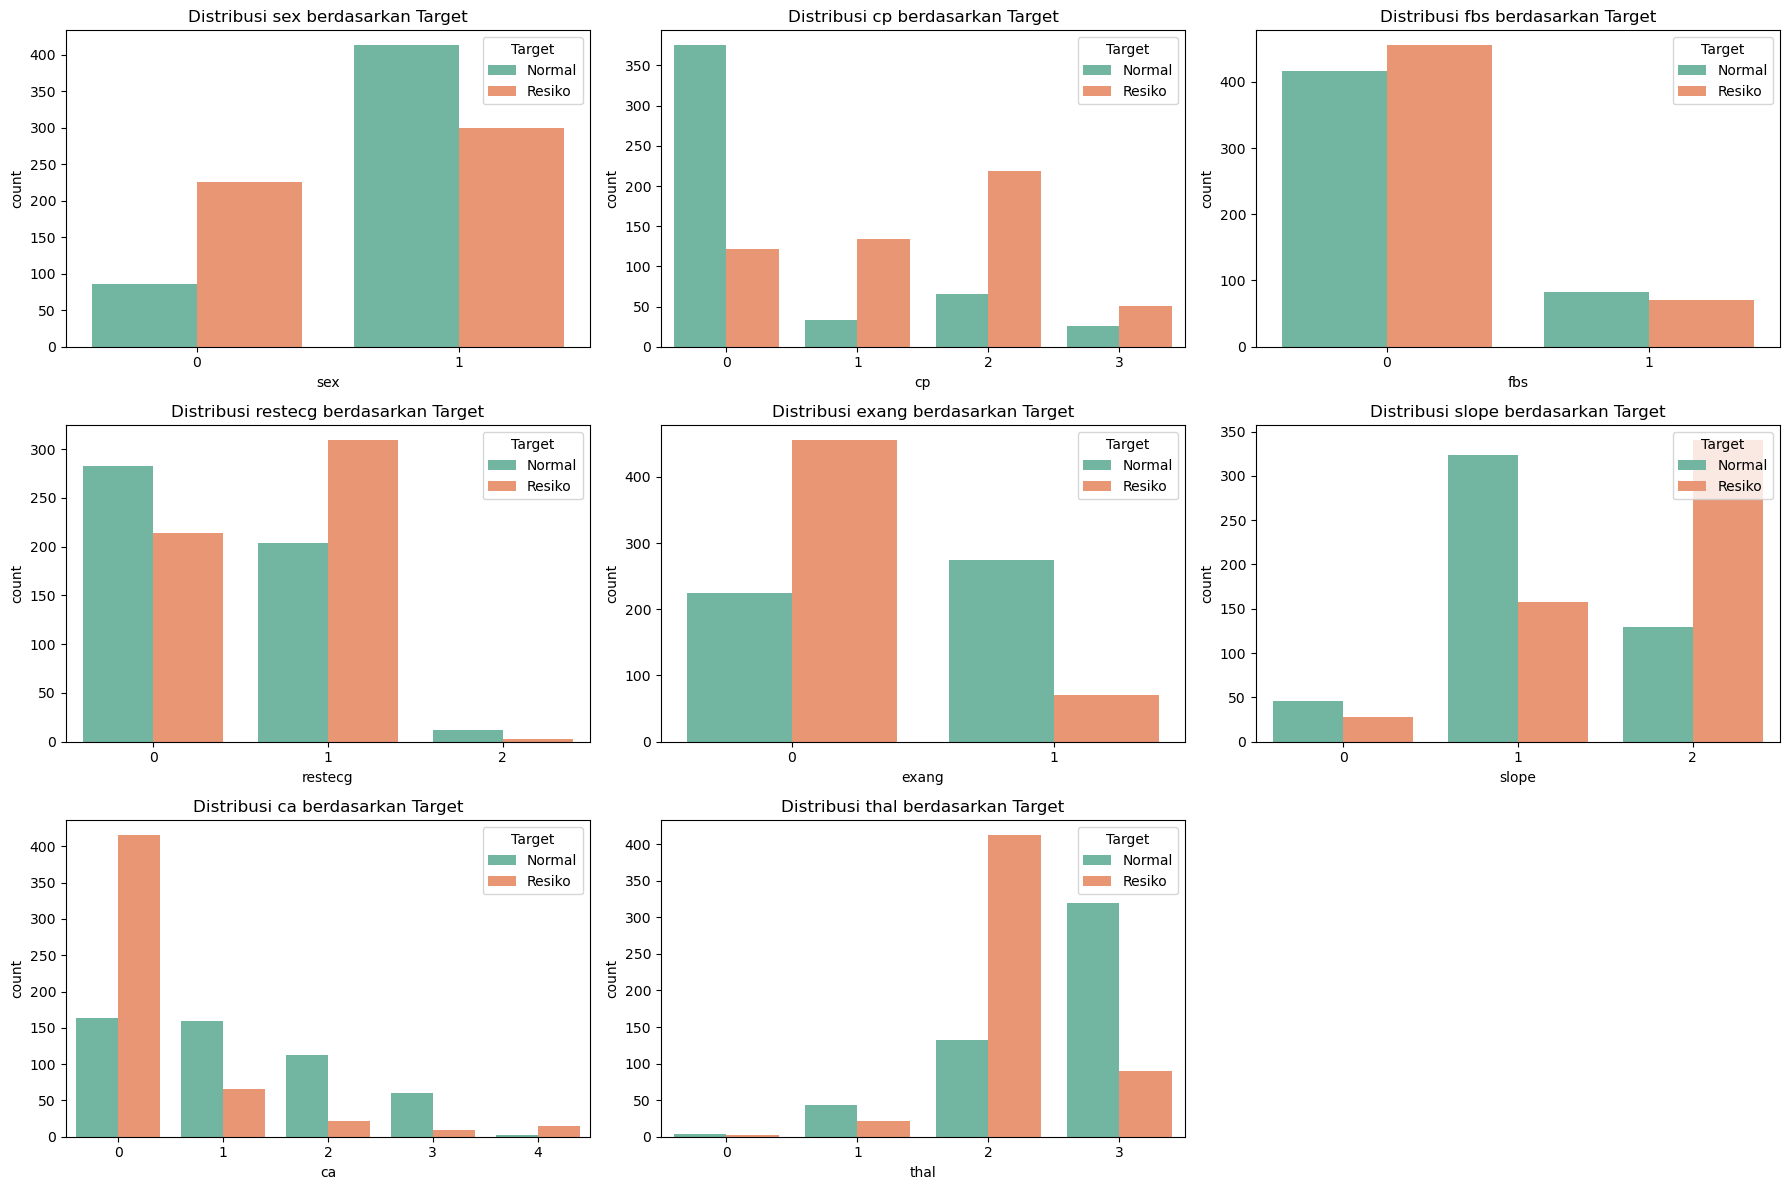

Deteksi Outlier dengan Boxplot:



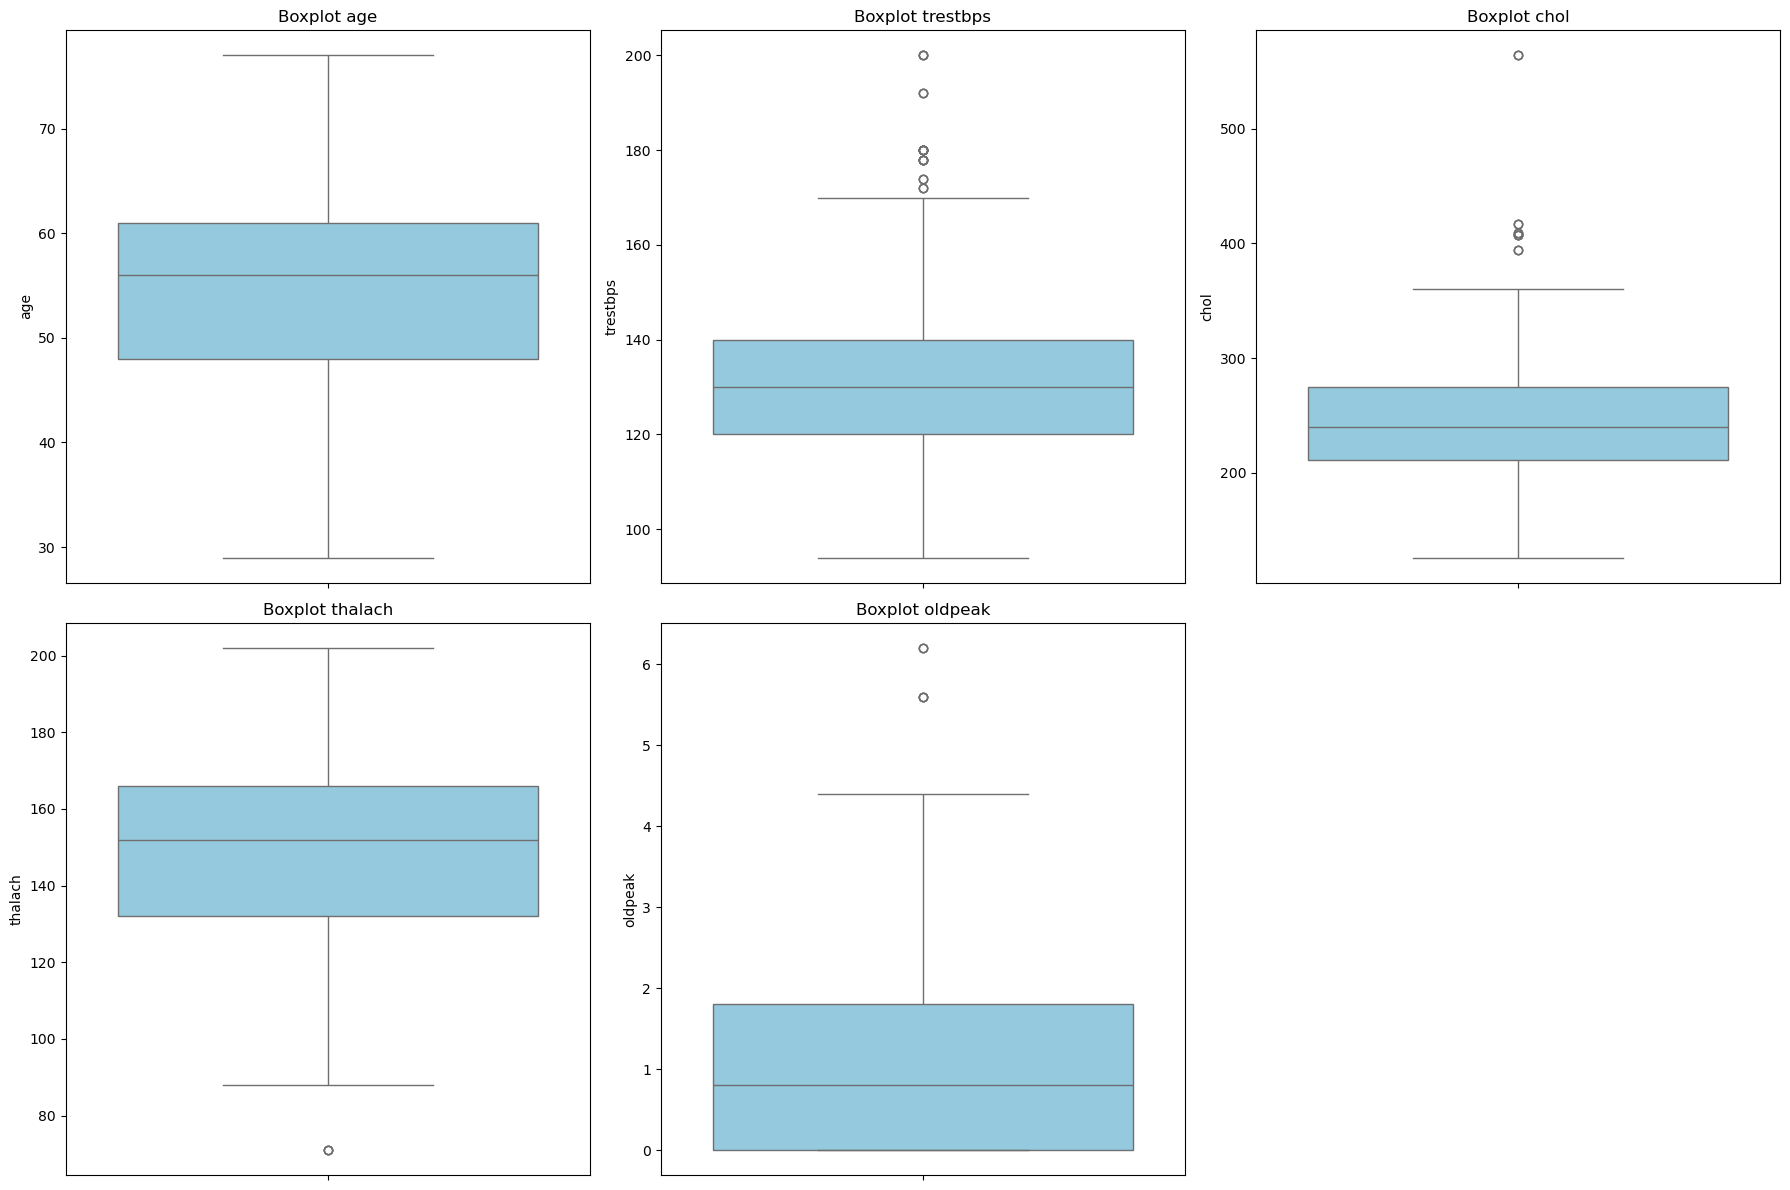

Heatmap Korelasi:



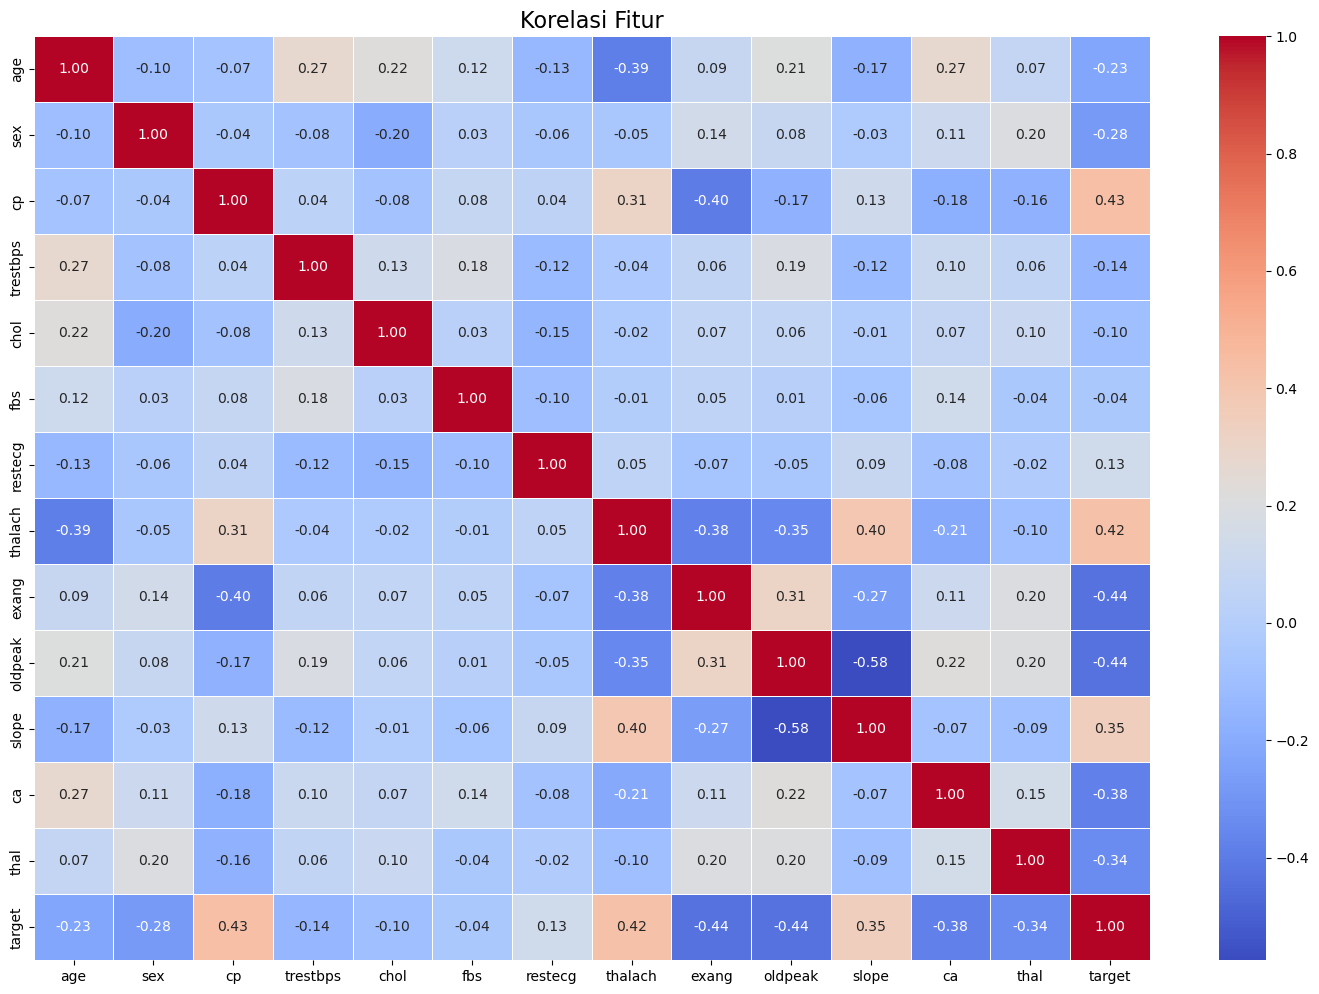

In [17]:
print("Informasi Terkait Dataset:")
df.info()
print("\n")

print("Statistik dari Dataset:")
display(df.describe())
print("\n")

print("Jumlah data yang hilang atau NULL:")
print(df.isnull().sum())
print("\n")

print("Jumlah data duplikat: %i" % df.duplicated().sum())
print("\n")


sns.set_palette("Set2")
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='target')
plt.title("Distribusi Target (1 = resiko kena penyakit jantung, 0 = normal)", fontsize=14)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points')
plt.show()


col_numerik = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
col_categorik = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print("Distribusi Fitur Numerik:\n")
plt.figure(figsize=(18, 12))
for i, col in enumerate(col_numerik):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title("Distribusi %s" % col)
plt.tight_layout()
plt.show()

print("Distribusi Fitur Kategorik berdasarkan Target:\n")
plt.figure(figsize=(18, 12))
for i, col in enumerate(col_categorik):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=df, x=col, hue='target')
    plt.title("Distribusi %s berdasarkan Target" % col)
    plt.legend(title="Target", loc="upper right", labels=["Normal", "Resiko"])
plt.tight_layout()
plt.show()

print("Deteksi Outlier dengan Boxplot:\n")
plt.figure(figsize=(18, 12))
for i, col in enumerate(col_numerik):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title("Boxplot %s" % col)
plt.tight_layout()
plt.show()

print("Heatmap Korelasi:\n")
plt.figure(figsize=(18, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Korelasi Fitur", fontsize=16)
plt.show()

# **5. Data Preprocessing**

Pada tahapan ini, data mengalami preprocessing berdasarkan informasi yang didapatkan dari EDA sebelumnya. Jadi pada eksperimen ini, beberapa tahap preprocessing yang dilakukan meliputi:
1. Hapus data duplikat
2. Hapus outlier (via IQR)
3. Split fitur dengan target
4. Split data train dengan data testing (80:20)
5. Encoding dan scaling data (cegah bias)

In [18]:
# Hapus duplikat
df_cleaned = df.drop_duplicates().reset_index(drop=True)
print("Data setelah hapus duplikat: %s\n" % str(df_cleaned.shape))

# Hapus outlier pake IQR
def threshold_outlier(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
    data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])
    return data

for col in ['trestbps', 'chol', 'thalach', 'oldpeak']:
    df_cleaned = threshold_outlier(df_cleaned, col)

# Split fitur dengan target
x = df_cleaned.drop('target', axis=1)
y = df_cleaned['target']

# Split data train dan test 80:20 + dengan statify untuk balance kelas
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Encoding dan scaling data biar ga bias
fitur_numerik = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fitur_categorikal = ['cp', 'restecg', 'slope', 'ca', 'thal'] 
fitur_biner = ['sex', 'fbs', 'exang']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), fitur_numerik),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), fitur_categorikal),
        ('passthrough', 'passthrough', fitur_biner)
    ]
)

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

# Nambah nama fitur hasil encoding untuk fitur kategorikal (one hot)
fitur_cat = preprocessor.named_transformers_['cat'].get_feature_names_out(fitur_categorikal)
fitur_all = fitur_numerik + list(fitur_cat) + fitur_biner

# Ubah kembali ke pandas dataframe
x_train_final = pd.DataFrame(x_train_processed, columns=fitur_all)
x_test_final = pd.DataFrame(x_test_processed, columns=fitur_all)

# Hasil akhir prepocessing
print("Data Train setelah Preprocessing:", x_train_final.shape)
print("Data Test setelah Preprocessing:", x_test_final.shape)
print("\n")

print("Preview data training setelah Prepocessing:")
display(x_train_final.head())

Data setelah hapus duplikat: (302, 14)

Data Train setelah Preprocessing: (241, 22)
Data Test setelah Preprocessing: (61, 22)


Preview data training setelah Prepocessing:


,age,trestbps,chol,thalach,oldpeak,cp_1,cp_2,cp_3,restecg_1,restecg_2,...,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3,sex,fbs,exang
0,1.421944,-0.996557,2.552393,0.409063,0.577073,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.465841,0.799455,-0.950296,-1.115983,-0.070646,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
2,0.422528,-0.191448,-0.621357,-0.891712,1.132260,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,1.644036,0.551729,0.159874,-0.218897,0.947198,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,-1.021072,-1.182351,-1.772645,-0.577732,-0.903428,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
